# <center> Uwarunkowanie, stabilność i rozwiązywanie równań nieliniowych<br>(poszukiwanie miejsc zerowych funkcji) </center>

# Uwarunkowanie i stabilność


***Zadanie 1. Czy wyznaczanie miejsc zerowych wielomianu może być zadaniem dobrze/źle uwarunkowanym? (Wielomian Wilkinsona)***

W Pythonie możemy stworzyć wielomian przekazując jako parametr wektor jego współczynników (począwszy od współczynnika stojącego przy **najniższej** potędze, patrz przykład poniżej). Proszę korzystać z modułu *numpy.polynomial* (zamiast *poly1d*).
* Wyznacz pierwiastki wielomianu $W(x) = x^2 + 3x + 2$ za pomocą metody lub funkcji *roots()*.
* Funkcja *Polynomial.fromroots* tworzy wielomian na podstawie listy przekazanych pierwiastków. Utwórz wielomian o następujących pierwiastkach $\{x_n = n, n = 1, 2, 3, . . . , 15\}$.
* Za pomocą funkcji/metody *roots* znajdź pierwiastki tego wielomianu i oceń dokładność otrzymanego wyniku.
* Do trzynastego elementu wektora współczynników wprowadź małe zaburzenie (np. rzędu $10^−5$) i znajdź pierwiastki wielomianu o zaburzonych współczynnikach. Wykreśl pierwiastki na płaszczyznie zespolonej. 
* Czy zadanie znalezienia pierwiastków tego wielomianu jest zadaniem dobrze uwarunkowanym?


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from numpy.polynomial import Polynomial
# Przykłady operacji na wielomianach
p = Polynomial([3, 2, 1]) # Od ostatniego współczynnika
print(p)
print(p.roots())
print(Polynomial.roots(p))




3.0 + 2.0 x + 1.0 x**2
[-1.-1.41421356j -1.+1.41421356j]
[-1.-1.41421356j -1.+1.41421356j]


Pierwiastki W(x) = x^2 + 3x + 2: [-2. -1.]

Pierwiastki wielomianu (oryginalne):
[ 1.          2.          3.          4.00000001  4.99999997  6.00000015
  6.99999933  8.00000223  8.99999482 10.00000797 10.99999226 12.0000043
 12.99999906 13.9999998  15.00000011]
Błąd max: 7.97e-06

Pierwiastki po zaburzeniu współczynnika:
[ 1.          2.          2.99999999  4.00000072  4.99997183  6.00050142
  6.99527259  8.02826967  8.91050855 10.34397423 10.56548305 12.51519101
 12.57393867 14.08234994 14.98453833]


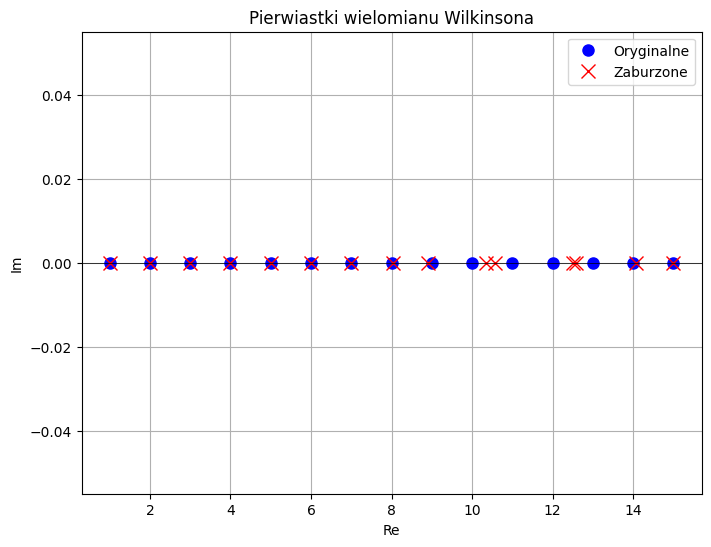


Zadanie znalezienia pierwiastków tego wielomianu jest ŹLE uwarunkowane -
małe zaburzenie współczynników powoduje duże zmiany w pierwiastkach.


In [3]:
from numpy.polynomial import Polynomial

# Wielomian W(x) = x^2 + 3x + 2
W = Polynomial([2, 3, 1])
print(f'Pierwiastki W(x) = x^2 + 3x + 2: {W.roots()}')

# Wielomian o pierwiastkach 1, 2, ..., 15
p = Polynomial.fromroots(np.arange(1, 16))
roots_p = p.roots()
print(f'\nPierwiastki wielomianu (oryginalne):')
print(np.sort(np.real(roots_p)))
print(f'Błąd max: {np.max(np.abs(np.sort(np.real(roots_p)) - np.arange(1, 16))):.2e}')

# Zaburzenie 13-go współczynnika
coefs = p.coef.copy()
coefs[12] += 1e-5
p_pert = Polynomial(coefs)
roots_pert = p_pert.roots()

print(f'\nPierwiastki po zaburzeniu współczynnika:')
print(roots_pert)

# Wykres na płaszczyźnie zespolonej
plt.figure(figsize=(8, 6))
plt.plot(np.real(roots_p), np.imag(roots_p), 'bo', markersize=8, label='Oryginalne')
plt.plot(np.real(roots_pert), np.imag(roots_pert), 'rx', markersize=10, label='Zaburzone')
plt.xlabel('Re')
plt.ylabel('Im')
plt.title('Pierwiastki wielomianu Wilkinsona')
plt.legend()
plt.grid()
plt.axhline(y=0, color='k', linewidth=0.5)
plt.show()

print('\nZadanie znalezienia pierwiastków tego wielomianu jest ŹLE uwarunkowane -')
print('małe zaburzenie współczynników powoduje duże zmiany w pierwiastkach.')

***Zadanie 2. Całka oznaczona***

Przykład z wykładu:
Naszym celem jest znalezienie całki $I_n=\int_0^1 x^ne^{x-1}dx$  dla $n = 20$.
* Na podstawie np. przybliżonych wykresów funkcji podcałkowej, proszę oszacować wartość tej całki oraz relację miedzy $I_n$ a $I_{n−1}$.
* Ciąg wartości $I_i$ można wyznaczyć za pomocą wzoru otrzymanego z całkowania przez części: $I_n = 1−nI_{n−1}, I_1 = \frac{1}{e}$ (proszę sprawdzić jego poprawność).
* Czy otrzymane wyniki są zgodne z przewidywaniami? Która operacja może powodować takie skutki?
* Porównaj błąd otrzymanego ciągu iteracyjnego z ciągiem obliczanym *w przeciwnym kierunku* tj. od $I_{20}$ do $I_1$. Proszę przyjąć, że $I_{20} = 0$.
* Jak duży jest błąd danej wejściowej ($I_{20}$) i ostatniego elementu ciągu ($I_1$)?
* Który algorytm jest stabilny, a który niestabilny?

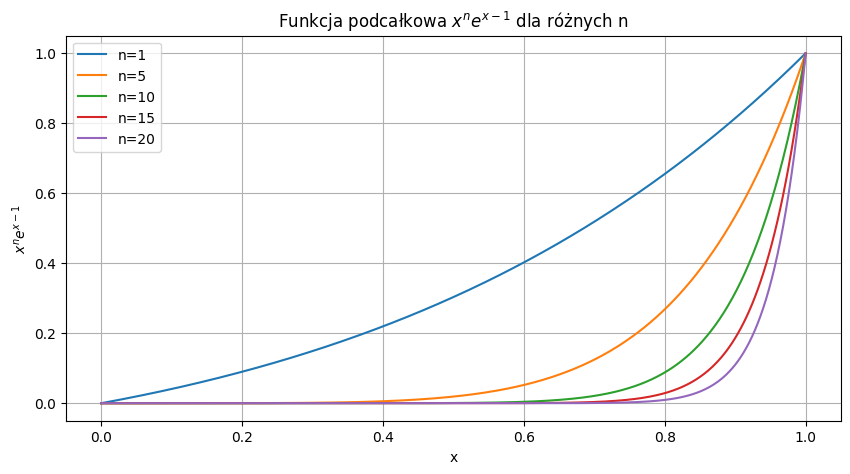

Oszacowanie: I_n jest malejące (bo x^n maleje na [0,1] ze wzrostem n).
Wszystkie I_n > 0 i I_n → 0 gdy n → ∞.
I_n < I_{n-1} (bo x^n < x^{n-1} dla x ∈ (0,1)).

Algorytm do przodu (I_1 -> I_20):
  I_ 1 = 0.3678794412
  I_ 2 = 0.2642411177
  I_ 3 = 0.2072766470
  I_ 4 = 0.1708934119
  I_ 5 = 0.1455329406
  I_ 6 = 0.1268023566
  I_ 7 = 0.1123835041
  I_ 8 = 0.1009319674
  I_ 9 = 0.0916122930
  I_10 = 0.0838770701
  I_11 = 0.0773522294
  I_12 = 0.0717732477
  I_13 = 0.0669477800
  I_14 = 0.0627310804
  I_15 = 0.0590337936
  I_16 = 0.0554593017
  I_17 = 0.0571918706
  I_18 = -0.0294536708
  I_19 = 1.5596197443
  I_20 = -30.1923948856

Algorytm do tyłu (I_20 -> I_1):
  I_ 1 = 0.3678794412
  I_ 2 = 0.2642411177
  I_ 3 = 0.2072766470
  I_ 4 = 0.1708934119
  I_ 5 = 0.1455329406
  I_ 6 = 0.1268023566
  I_ 7 = 0.1123835041
  I_ 8 = 0.1009319674
  I_ 9 = 0.0916122930
  I_10 = 0.0838770701
  I_11 = 0.0773522289
  I_12 = 0.0717732536
  I_13 = 0.0669477027
  I_14 = 0.0627321623
  I_15 = 0.0590175654
 

In [4]:
# Zadanie 2 - Całka oznaczona I_n = integral(x^n * e^(x-1), 0, 1)

# Wykres funkcji podcałkowej dla kilku wartości n
x = np.linspace(0, 1, 500)
plt.figure(figsize=(10, 5))
for n in [1, 5, 10, 15, 20]:
    plt.plot(x, x**n * np.exp(x - 1), label=f'n={n}')
plt.xlabel('x')
plt.ylabel('$x^n e^{x-1}$')
plt.title('Funkcja podcałkowa $x^n e^{x-1}$ dla różnych n')
plt.legend()
plt.grid()
plt.show()

print('Oszacowanie: I_n jest malejące (bo x^n maleje na [0,1] ze wzrostem n).')
print('Wszystkie I_n > 0 i I_n → 0 gdy n → ∞.')
print('I_n < I_{n-1} (bo x^n < x^{n-1} dla x ∈ (0,1)).')
print()

# Algorytm "do przodu": I_1 = 1/e, I_n = 1 - n*I_{n-1}
e = np.e
I_forward = np.zeros(21)
I_forward[1] = 1.0 / e

for n in range(2, 21):
    I_forward[n] = 1.0 - n * I_forward[n - 1]

print('Algorytm do przodu (I_1 -> I_20):')
for n in range(1, 21):
    print(f'  I_{n:2d} = {I_forward[n]:.10f}')

# Algorytm "do tyłu": I_20 ≈ 0, I_{n-1} = (1 - I_n) / n
I_backward = np.zeros(21)
I_backward[20] = 0.0  # przybliżenie

for n in range(20, 1, -1):
    I_backward[n - 1] = (1.0 - I_backward[n]) / n

print('\nAlgorytm do tyłu (I_20 -> I_1):')
for n in range(1, 21):
    print(f'  I_{n:2d} = {I_backward[n]:.10f}')

# Porównanie z wartością dokładną I_1 = 1/e
print(f'\nWartość dokładna I_1 = 1/e = {1/e:.10f}')
print(f'I_1 (do przodu):  {I_forward[1]:.10f} — błąd: {abs(I_forward[1] - 1/e):.2e}')
print(f'I_1 (do tyłu):    {I_backward[1]:.10f} — błąd: {abs(I_backward[1] - 1/e):.2e}')
print(f'I_20 (do przodu): {I_forward[20]:.10f} — wartości ujemne/duże = brak sensu')
print(f'I_20 (do tyłu):   {I_backward[20]:.10f} — błąd danych wejściowych jest tłumiony')
print(f'\nBłąd danej wejściowej I_20 w algorytmie wstecz: ok. {I_backward[19]/(20+1):.2e} (mały)')
print('Błąd I_1 w algorytmie wstecz: praktycznie 0 (dzielenie przez n tłumi błąd).')

print('\nAlgorytm do przodu jest NIESTABILNY (mnożenie przez n wzmacnia błędy).')
print('Algorytm do tyłu jest STABILNY (dzielenie przez n tłumi błędy).')
print('Operacją powodującą niestabilność jest odejmowanie bliskich sobie liczb (1 - n*I_{n-1})')
print('połączone z mnożeniem przez rosnące n, co wzmacnia błędy zaokrągleń.')

# Poszukiwanie miejsc zerowych

Dana jest funkcja $$f(x) = e^{-2x}+x^2-1$$

***Zadanie 1.***

Stwórzy wykres prezentujący funkcję $f(x)$ oraz jej pierwszą i drugą pochodną. Na podstawie spróbuj oszacować wartości pierwiastków równania $f(x) = 0$.

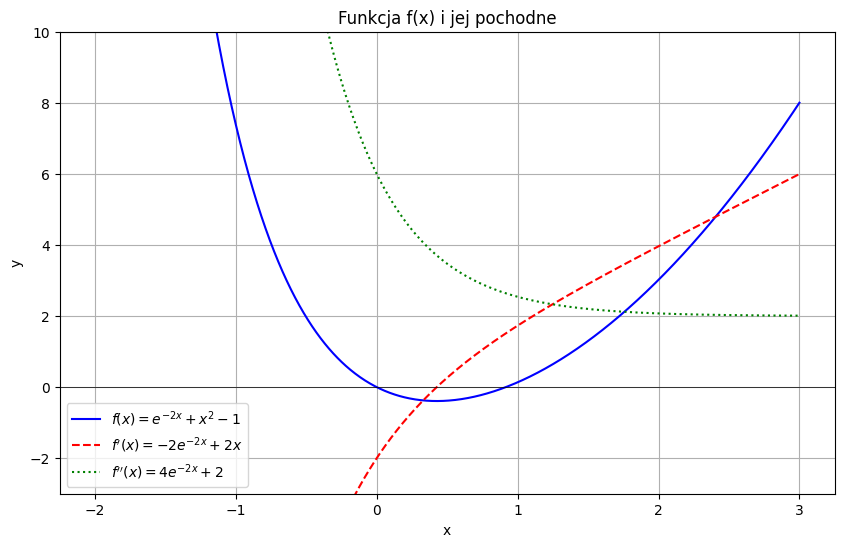

Z wykresu widać, że f(x) = 0 ma dwa pierwiastki:
  - x = 0 (bo f(0) = e^0 + 0 - 1 = 0.0)
  - x ≈ 0.9 (widać na wykresie, że f zmienia znak w okolicy x ∈ [0.8, 1.0])


In [5]:
# Zadanie 1 - Wykres f(x) = e^(-2x) + x^2 - 1 oraz pochodnych

def f(x):
    return np.exp(-2*x) + x**2 - 1

def f_prim(x):
    return -2*np.exp(-2*x) + 2*x

def f_bis(x):
    return 4*np.exp(-2*x) + 2

x = np.linspace(-2, 3, 1000)

plt.figure(figsize=(10, 6))
plt.plot(x, f(x), 'b-', label="$f(x) = e^{-2x} + x^2 - 1$")
plt.plot(x, f_prim(x), 'r--', label="$f'(x) = -2e^{-2x} + 2x$")
plt.plot(x, f_bis(x), 'g:', label="$f''(x) = 4e^{-2x} + 2$")
plt.axhline(y=0, color='k', linewidth=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Funkcja f(x) i jej pochodne')
plt.legend()
plt.grid()
plt.ylim([-3, 10])
plt.show()

print('Z wykresu widać, że f(x) = 0 ma dwa pierwiastki:')
print(f'  - x = 0 (bo f(0) = e^0 + 0 - 1 = {f(0):.1f})')
print(f'  - x ≈ 0.9 (widać na wykresie, że f zmienia znak w okolicy x ∈ [0.8, 1.0])')

***Zadanie 2.***

Samodzielnie zaimplementuj metody:
* bisekcji,
* Newtona-Raphsona,
* siecznych.

Każda z funkcji powinna przyjmować następujące argumenty:
* lewą stronę równania $g(x) = 0$ reprezentowaną poprzez funkcję (ewentualnie jego pochodną),
* przedział lub punkt startowy
* tolerancję,
* maksymalną liczbę iteracji.

i zwracać:
* znaleziony pierwiastek,
* liczbę iteracji.

W jaki sposób sprawdzić warunek stopu? Czy kryterium stopu polegające na kontynuacji iteracji dopóki $x_{i+1}\neq x_i$ jest prawidłowe (bezpieczne)?

In [6]:
# Zadanie 2 - Implementacja metod: bisekcji, Newtona-Raphsona, siecznych

def bisection(g, a, b, tol=1e-6, max_iter=1000):
    if g(a) * g(b) > 0:
        raise ValueError("f(a) i f(b) muszą mieć różne znaki")
    n_iter = 0
    for i in range(max_iter):
        c = (a + b) / 2.0
        n_iter += 1
        if abs(g(c)) < tol or (b - a) / 2.0 < tol:
            return c, n_iter
        if g(a) * g(c) < 0:
            b = c
        else:
            a = c
    return c, n_iter

def newton_raphson(g, g_prim, x0, tol=1e-6, max_iter=1000):
    x = x0
    for i in range(1, max_iter + 1):
        fx = g(x)
        fpx = g_prim(x)
        if abs(fpx) < 1e-14:
            break
        x_new = x - fx / fpx
        if abs(x_new - x) < tol:
            return x_new, i
        x = x_new
    return x, max_iter

def secant(g, x0, x1, tol=1e-6, max_iter=1000):
    for i in range(1, max_iter + 1):
        f0 = g(x0)
        f1 = g(x1)
        if abs(f1 - f0) < 1e-14:
            break
        x_new = x1 - f1 * (x1 - x0) / (f1 - f0)
        if abs(x_new - x1) < tol:
            return x_new, i
        x0 = x1
        x1 = x_new
    return x1, max_iter

print('Metody zaimplementowane: bisection, newton_raphson, secant')
print()
print('Warunek stopu: |x_{i+1} - x_i| < tol lub |f(x)| < tol')
print('Warunek x_{i+1} != x_i NIE jest bezpieczny — może prowadzić do')
print('nieskończonej pętli z powodu oscylacji między sąsiednimi liczbami zmiennoprzecinkowymi.')

Metody zaimplementowane: bisection, newton_raphson, secant

Warunek stopu: |x_{i+1} - x_i| < tol lub |f(x)| < tol
Warunek x_{i+1} != x_i NIE jest bezpieczny — może prowadzić do
nieskończonej pętli z powodu oscylacji między sąsiednimi liczbami zmiennoprzecinkowymi.


***Zadanie 3.***

Wykorzystaj stworzone w zadaniu 2. metody do znalezienia miejsc zerowych funkcji $f(x)$ z dokładnością $\epsilon = 10^{-6}$. Porównaj liczby iteracji niezbędnych do znalezienia pierwiastka. Która metoda sprawdziła się najlepiej? Która wypada najgorzej? Czy odpowiedni dobór przedziału może przyspieszyć proces rozwiązywania? Eksperyment przeprowadź dla wszystkich miejsc zerowych $f(x)$.


In [7]:
# Zadanie 3 - Znalezienie miejsc zerowych f(x) = e^(-2x) + x^2 - 1

eps = 1e-6

# Pierwiastek 1: x = 0  (f(-1) > 0, f(0.1) < 0)
print('=== Pierwiastek 1 (okolice x = 0) ===')
x_bis1, it_bis1 = bisection(f, -1, 0.1, tol=eps)
x_nr1, it_nr1 = newton_raphson(f, f_prim, -0.5, tol=eps)
x_sec1, it_sec1 = secant(f, -0.5, -0.1, tol=eps)

print(f'Bisekcja:       x = {x_bis1:.8f}, iteracje: {it_bis1}, f(x) = {f(x_bis1):.2e}')
print(f'Newton-Raphson: x = {x_nr1:.8f}, iteracje: {it_nr1}, f(x) = {f(x_nr1):.2e}')
print(f'Sieczne:        x = {x_sec1:.8f}, iteracje: {it_sec1}, f(x) = {f(x_sec1):.2e}')

# Pierwiastek 2: x ≈ 0.917  (f(0.5) < 0, f(2) > 0)
print('\n=== Pierwiastek 2 (okolice x ≈ 0.917) ===')
x_bis2, it_bis2 = bisection(f, 0.5, 2, tol=eps)
x_nr2, it_nr2 = newton_raphson(f, f_prim, 1.0, tol=eps)
x_sec2, it_sec2 = secant(f, 0.5, 1.5, tol=eps)

print(f'Bisekcja:       x = {x_bis2:.8f}, iteracje: {it_bis2}, f(x) = {f(x_bis2):.2e}')
print(f'Newton-Raphson: x = {x_nr2:.8f}, iteracje: {it_nr2}, f(x) = {f(x_nr2):.2e}')
print(f'Sieczne:        x = {x_sec2:.8f}, iteracje: {it_sec2}, f(x) = {f(x_sec2):.2e}')

print('\nNewton-Raphson jest najszybszy (najmniej iteracji).')
print('Bisekcja jest najwolniejsza ale gwarantuje zbieżność.')
print('Węższy przedział początkowy przyspiesza bisekcję i zapobiega zbieżności do złego pierwiastka.')

=== Pierwiastek 1 (okolice x = 0) ===
Bisekcja:       x = 0.00000010, iteracje: 20, f(x) = -1.91e-07
Newton-Raphson: x = -0.00000000, iteracje: 6, f(x) = 0.00e+00
Sieczne:        x = -0.00000000, iteracje: 6, f(x) = 2.42e-14

=== Pierwiastek 2 (okolice x ≈ 0.917) ===
Bisekcja:       x = 0.91656208, iteracje: 19, f(x) = -7.61e-07
Newton-Raphson: x = 0.91656258, iteracje: 4, f(x) = 0.00e+00
Sieczne:        x = 0.91656258, iteracje: 7, f(x) = -2.25e-13

Newton-Raphson jest najszybszy (najmniej iteracji).
Bisekcja jest najwolniejsza ale gwarantuje zbieżność.
Węższy przedział początkowy przyspiesza bisekcję i zapobiega zbieżności do złego pierwiastka.


***Zadanie 4.***

Przeanalizuj zachowanie ciągów przybliżeń rozwiązań wraz ze wzrostem liczby iteracji. Przedstaw wyniki w postaci wykresu i dokonaj ich analizy.

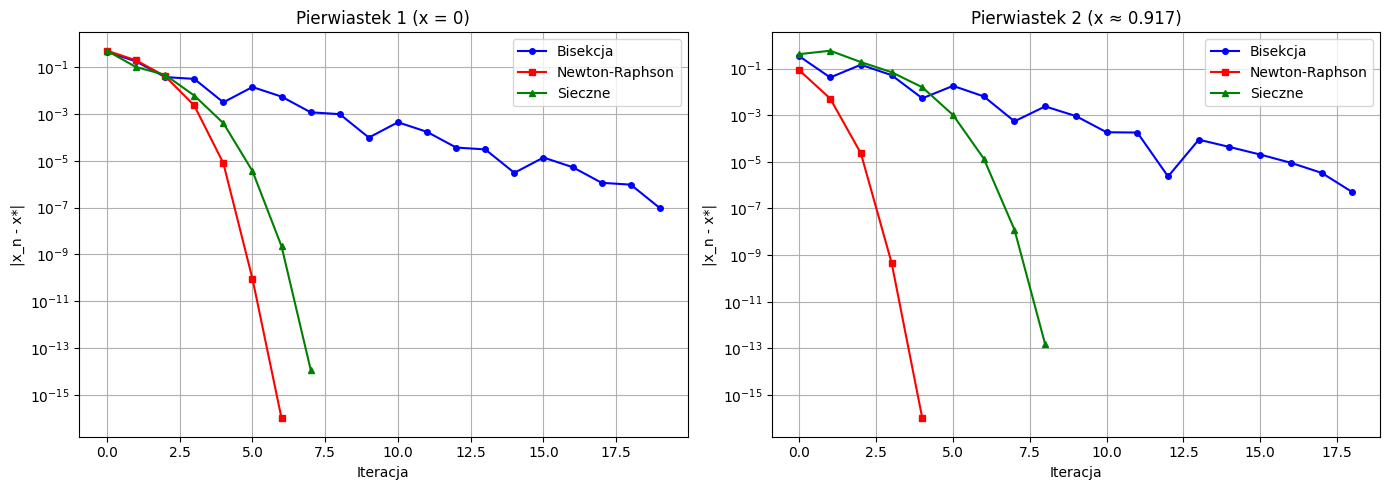

Newton-Raphson zbiega najszybciej (zbieżność kwadratowa).
Sieczne zbiegają szybciej niż bisekcja (rząd ≈ 1.618).
Bisekcja ma zbieżność liniową (co iterację błąd maleje o połowę).


In [8]:
# Zadanie 4 - Analiza zbieżności ciągów przybliżeń

def bisection_history(g, a, b, tol=1e-6, max_iter=1000):
    history = []
    for i in range(max_iter):
        c = (a + b) / 2.0
        history.append(c)
        if abs(g(c)) < tol or (b - a) / 2.0 < tol:
            break
        if g(a) * g(c) < 0:
            b = c
        else:
            a = c
    return history

def newton_history(g, g_prim, x0, tol=1e-6, max_iter=1000):
    history = [x0]
    x = x0
    for i in range(max_iter):
        x_new = x - g(x) / g_prim(x)
        history.append(x_new)
        if abs(x_new - x) < tol:
            break
        x = x_new
    return history

def secant_history(g, x0, x1, tol=1e-6, max_iter=1000):
    history = [x0, x1]
    for i in range(max_iter):
        f0, f1 = g(x0), g(x1)
        if abs(f1 - f0) < 1e-14:
            break
        x_new = x1 - f1 * (x1 - x0) / (f1 - f0)
        history.append(x_new)
        if abs(x_new - x1) < tol:
            break
        x0 = x1
        x1 = x_new
    return history

# Dla obu pierwiastków
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (title, a, b, x0_nr, x0_s, x1_s) in enumerate([
    ('Pierwiastek 1 (x = 0)', -1, 0.1, -0.5, -0.5, -0.1),
    ('Pierwiastek 2 (x ≈ 0.917)', 0.5, 2, 1.0, 0.5, 1.5)
]):
    h_bis = bisection_history(f, a, b)
    h_nr = newton_history(f, f_prim, x0_nr)
    h_sec = secant_history(f, x0_s, x1_s)
    
    # Wartość dokładna (ostatni element Newtona)
    x_exact = h_nr[-1]
    
    err_bis = [abs(x - x_exact) for x in h_bis]
    err_nr = [abs(x - x_exact) for x in h_nr]
    err_sec = [abs(x - x_exact) for x in h_sec]
    
    # Zastąp zera małą wartością dla wykresu log
    err_bis = [max(e, 1e-16) for e in err_bis]
    err_nr = [max(e, 1e-16) for e in err_nr]
    err_sec = [max(e, 1e-16) for e in err_sec]
    
    axes[idx].semilogy(err_bis, 'b-o', markersize=4, label='Bisekcja')
    axes[idx].semilogy(err_nr, 'r-s', markersize=4, label='Newton-Raphson')
    axes[idx].semilogy(err_sec, 'g-^', markersize=4, label='Sieczne')
    axes[idx].set_title(title)
    axes[idx].set_xlabel('Iteracja')
    axes[idx].set_ylabel('|x_n - x*|')
    axes[idx].legend()
    axes[idx].grid()

plt.tight_layout()
plt.show()

print('Newton-Raphson zbiega najszybciej (zbieżność kwadratowa).')
print('Sieczne zbiegają szybciej niż bisekcja (rząd ≈ 1.618).')
print('Bisekcja ma zbieżność liniową (co iterację błąd maleje o połowę).')